In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [5]:
np.random.seed(42)
n = 500
data = pd.DataFrame({
    'CustomerID': range(1, n+1),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Age': np.random.randint(18, 70, n),
    'Annual_Income': np.random.randint(20, 150, n),
    'Spending_Score': np.random.randint(1, 100, n),
    'Purchase_Frequency': np.random.randint(1, 50, n),
    'Avg_Order_Value': np.random.randint(20, 500, n)
})
data.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Purchase_Frequency,Avg_Order_Value
0,1,Male,38,71,4,32,446
1,2,Female,49,98,93,41,162
2,3,Male,40,49,86,36,361
3,4,Male,50,125,25,34,335
4,5,Male,20,70,13,36,120


In [6]:
print("Shape:", data.shape)
print("\nData Types:\n", data.dtypes)
print("\nMissing Values:\n", data.isnull().sum())
print("\nSummary Statistics:")
data.describe()

Shape: (500, 7)

Data Types:
 CustomerID             int64
Gender                object
Age                    int32
Annual_Income          int32
Spending_Score         int32
Purchase_Frequency     int32
Avg_Order_Value        int32
dtype: object

Missing Values:
 CustomerID            0
Gender                0
Age                   0
Annual_Income         0
Spending_Score        0
Purchase_Frequency    0
Avg_Order_Value       0
dtype: int64

Summary Statistics:


,CustomerID,Age,Annual_Income,Spending_Score,Purchase_Frequency,Avg_Order_Value
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,43.800000,82.854000,50.548000,24.726000,255.444000
std,144.481833,14.835504,37.593926,28.885367,14.555365,140.561595
min,1.000000,18.000000,20.000000,1.000000,1.000000,22.000000
25%,125.750000,31.000000,51.000000,25.000000,12.000000,136.750000
50%,250.500000,44.000000,81.000000,50.000000,25.000000,250.000000
75%,375.250000,56.000000,117.000000,76.000000,37.000000,385.250000
max,500.000000,69.000000,149.000000,99.000000,49.000000,499.000000


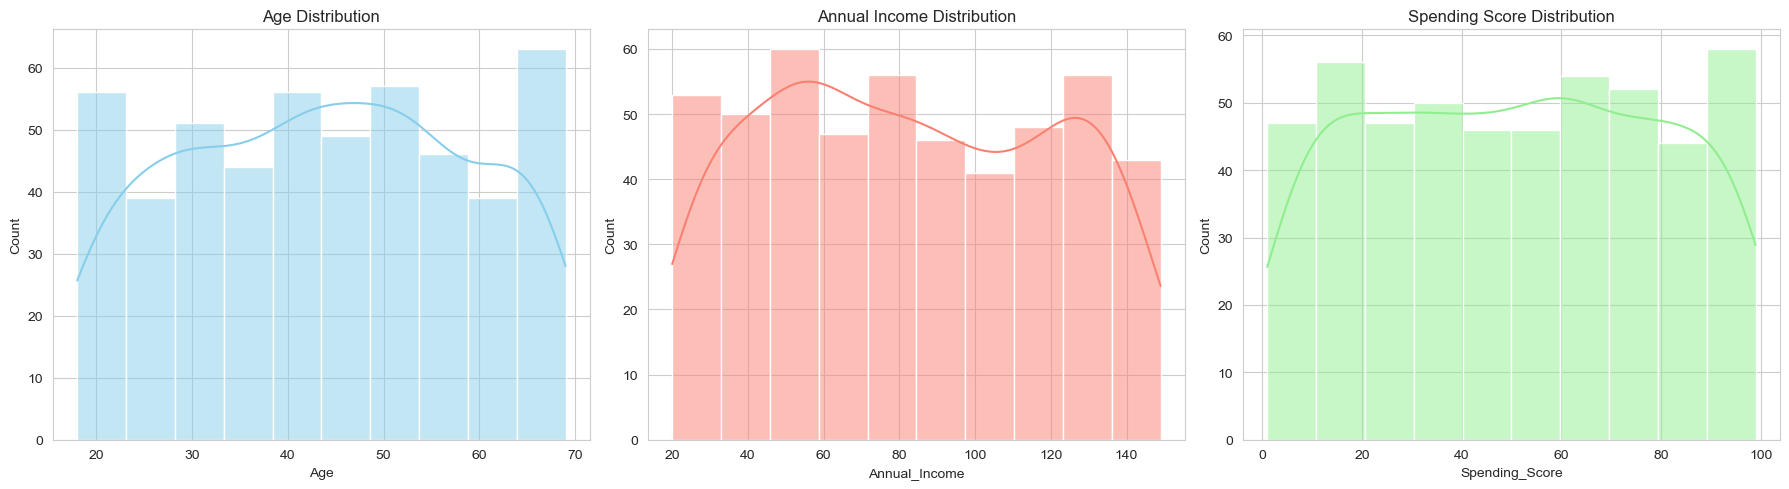

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(data['Annual_Income'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution')

sns.histplot(data['Spending_Score'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

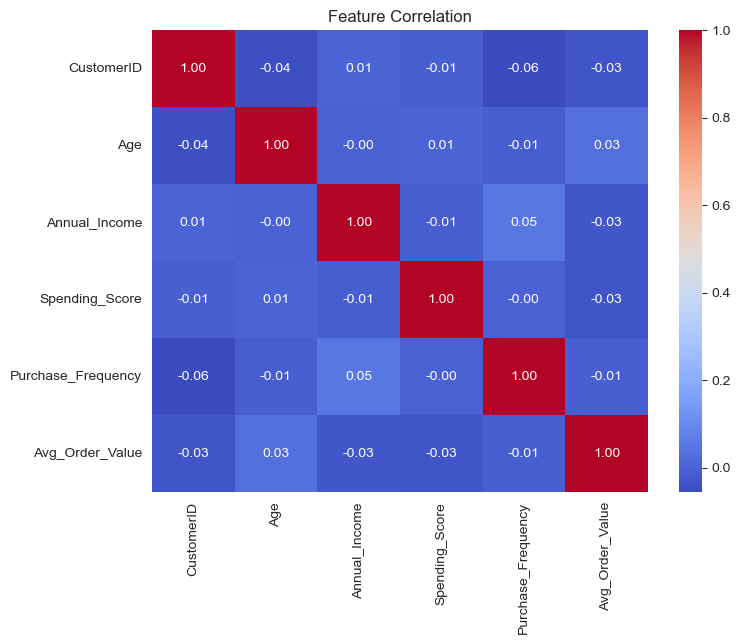

In [8]:
plt.figure(figsize=(8, 6))
numeric = data.select_dtypes(include=np.number)
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.show()

In [9]:
# Select features (adjust based on your dataset)
features = ['Age', 'Annual_Income', 'Spending_Score']
X = data[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Data scaled successfully")
print("Shape:", X_scaled.shape)

✅ Data scaled successfully
Shape: (500, 3)


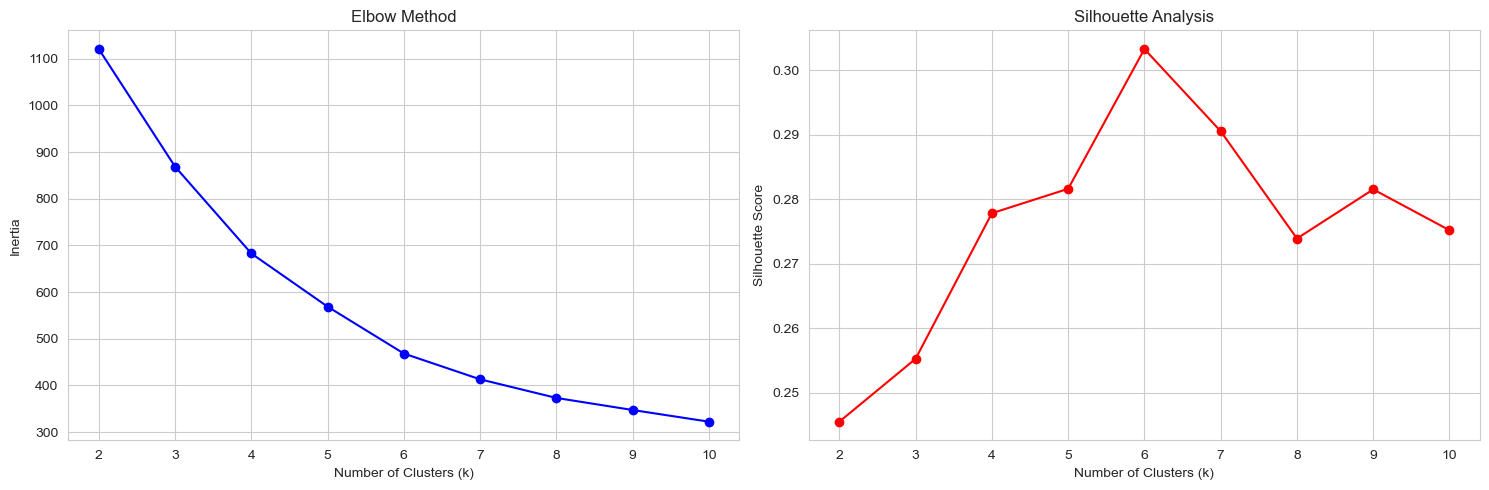

✅ Optimal number of clusters: 6


In [11]:
inertia = []
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(K, inertia, 'bo-')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow Method')

ax[1].plot(K, sil_scores, 'ro-')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

optimal_k = K[np.argmax(sil_scores)]
print(f"✅ Optimal number of clusters: {optimal_k}")

In [12]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Segment'] = kmeans.fit_predict(X_scaled)

print("✅ Clustering complete")
print("\nCustomers per segment:")
print(data['Segment'].value_counts().sort_index())

✅ Clustering complete

Customers per segment:
Segment
0    75
1    82
2    88
3    97
4    77
5    81
Name: count, dtype: int64


In [13]:
profile = data.groupby('Segment')[features].mean().round(2)
print("Average values per segment:")
profile

Average values per segment:


,Age,Annual_Income,Spending_Score
Segment,,,
0,26.84,108.52,69.57
1,45.37,121.50,23.16
2,29.77,59.86,26.51
3,45.53,47.25,80.82
4,57.16,118.05,71.60
5,58.40,54.12,30.51


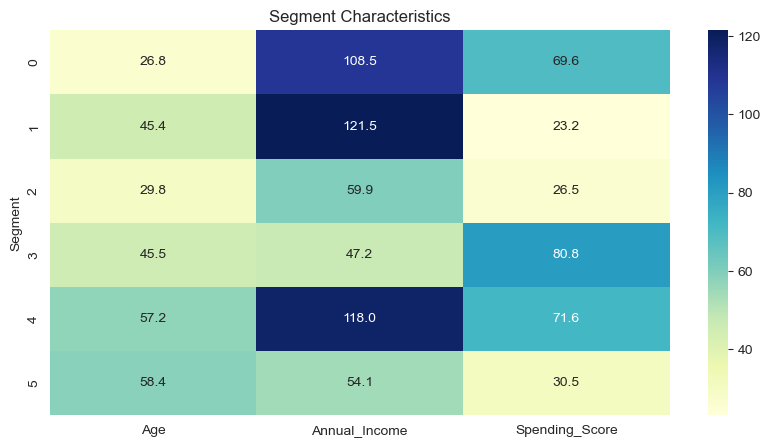

In [14]:
plt.figure(figsize=(10, 5))
sns.heatmap(profile, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Segment Characteristics')
plt.show()

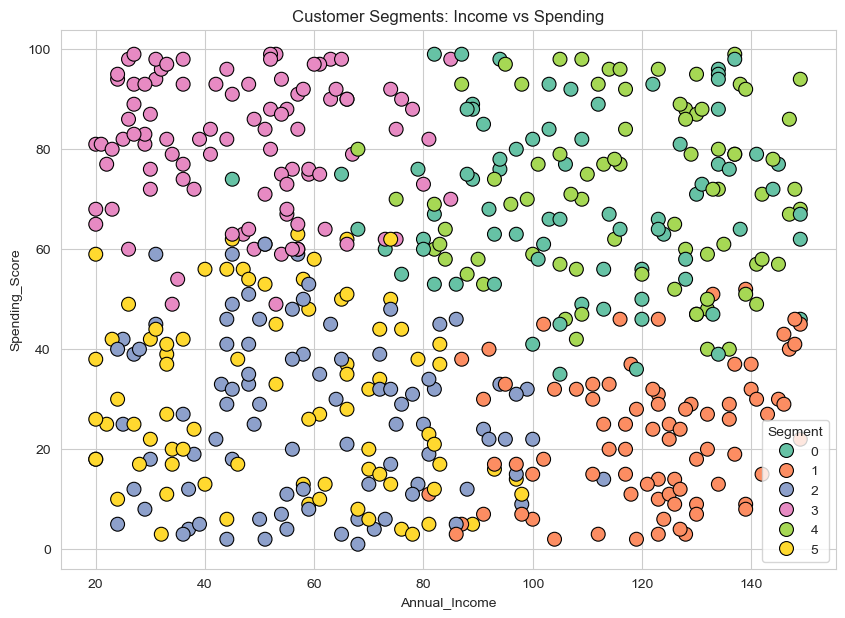

In [15]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=data, x='Annual_Income', y='Spending_Score',
                hue='Segment', palette='Set2', s=100, edgecolor='black')
plt.title('Customer Segments: Income vs Spending')
plt.legend(title='Segment')
plt.show()

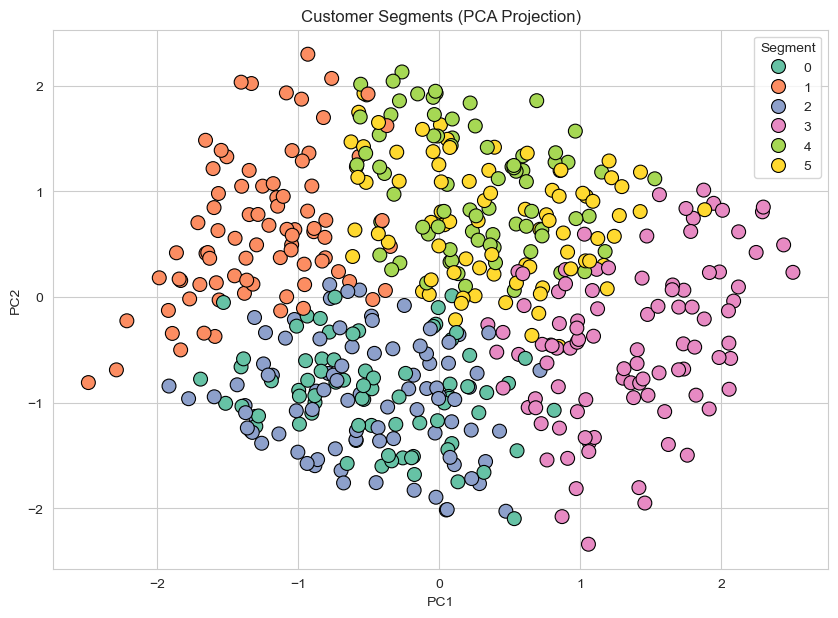

In [16]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
data['PC1'] = components[:, 0]
data['PC2'] = components[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=data, x='PC1', y='PC2', hue='Segment',
                palette='Set2', s=100, edgecolor='black')
plt.title('Customer Segments (PCA Projection)')
plt.show()

data.to_csv('Customer_Segments_Output.csv', index=False)
print("✅ Results saved to 'Customer_Segments_Output.csv'")

## 🎯 Business Insights

| Segment | Profile | Marketing Strategy |
|---------|---------|-------------------|
| 0 | High Income, High Spending | VIP / Premium offers |
| 1 | Low Income, Low Spending | Discount campaigns |
| 2 | High Income, Low Spending | Upsell / Engagement |
| 3 | Low Income, High Spending | Loyalty programs |
| 4 | Average across all | Standard marketing |